# Stage 4: Outfit Generation and Ranking

This notebook covers generating outfit recommendations from a wardrobe.

**Objectives:**
- Load trained models
- Create a sample wardrobe
- Generate outfit recommendations
- Explain why outfits work together

In [1]:
# Setup and imports
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

from src.recognition.classifier import GarmentClassifier, get_device
from src.attributes.color_extractor import ColorExtractor, ColorHarmonyAnalyzer
from src.attributes.pipeline import AttributePipeline
from src.compatibility.model import SiameseCompatibilityNet
from src.compatibility.scorer import CompatibilityScorer
from src.generation.generator import (
    OutfitGenerator, Wardrobe, WardrobeItem, OutfitTemplate
)
from src.generation.explainer import OutfitExplainer, QuickExplainer

device = get_device()
print(f"Using device: {device}")

/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cuda


## 4.1 Load Trained Models

In [2]:
MODEL_DIR = Path('../models')

# Load classifier
classifier_path = MODEL_DIR / 'garment_classifier.pth'
if classifier_path.exists():
    classifier = GarmentClassifier.load(classifier_path)
    print("Loaded trained classifier")
else:
    classifier = GarmentClassifier(backbone="efficientnet_b0", pretrained=True)
    classifier.to(device)
    classifier.device = device
    print("Using pretrained backbone")

# Load color extractor
color_extractor = ColorExtractor(n_colors=5, color_space='LAB')

# Load compatibility model
compat_path = MODEL_DIR / 'compatibility_model.pth'
if compat_path.exists():
    compat_model = SiameseCompatibilityNet.load(str(compat_path))
    print("Loaded trained compatibility model")
else:
    compat_model = SiameseCompatibilityNet()
    compat_model.to(device)
    print("Using untrained compatibility model (for demo only)")

# Create pipeline and scorer
pipeline = AttributePipeline(classifier=classifier, color_extractor=color_extractor)
scorer = CompatibilityScorer(
    model=compat_model,
    classifier=classifier,
    color_extractor=color_extractor
)

print("\nAll models loaded!")

Loaded trained classifier
Loaded trained compatibility model

All models loaded!


## 4.2 Create Sample Wardrobe

For demonstration, we'll create a synthetic wardrobe with sample items.

In [3]:
# Create sample images (colored rectangles)
def create_sample_item(color, category, category_id):
    """Create a sample wardrobe item with random features."""
    # Create sample image
    img = np.ones((224, 224, 3), dtype=np.uint8) * np.array(color, dtype=np.uint8)
    
    # Extract features
    visual_features = classifier.get_features(img)
    
    # Get colors
    colors = color_extractor.extract(img)
    color_vector = color_extractor.get_color_vector(img)
    
    return WardrobeItem(
        item_id=f"{category}_{color[0]}_{color[1]}_{color[2]}",
        category=category,
        category_id=category_id,
        image_path="synthetic",
        visual_features=visual_features,
        color_features=color_vector,
        dominant_colors=colors,
        metadata={"color_rgb": color}
    )

In [4]:
# Create a sample wardrobe
wardrobe = Wardrobe()

# Tops (various colors)
tops = [
    ([255, 255, 255], "White T-shirt"),
    ([30, 50, 100], "Navy Shirt"),
    ([50, 50, 50], "Black Top"),
    ([200, 200, 200], "Gray Sweater"),
    ([100, 150, 200], "Light Blue Blouse"),
]

# Bottoms
bottoms = [
    ([30, 40, 80], "Dark Jeans"),
    ([200, 180, 160], "Khaki Pants"),
    ([0, 0, 0], "Black Pants"),
    ([100, 100, 100], "Gray Trousers"),
]

# Shoes
shoes = [
    ([255, 255, 255], "White Sneakers"),
    ([0, 0, 0], "Black Shoes"),
    ([139, 69, 19], "Brown Boots"),
]

# Add to wardrobe
print("Creating wardrobe items...")
for color, name in tops:
    item = create_sample_item(color, "tops", 0)
    item.metadata["name"] = name
    wardrobe.add_item(item)
    print(f"  Added: {name}")

for color, name in bottoms:
    item = create_sample_item(color, "bottoms", 1)
    item.metadata["name"] = name
    wardrobe.add_item(item)
    print(f"  Added: {name}")

for color, name in shoes:
    item = create_sample_item(color, "shoes", 3)
    item.metadata["name"] = name
    wardrobe.add_item(item)
    print(f"  Added: {name}")

print(f"\nWardrobe created with {len(wardrobe)} items")
print(f"Categories: {wardrobe.get_category_counts()}")

Creating wardrobe items...
  Added: White T-shirt
  Added: Navy Shirt
  Added: Black Top
  Added: Gray Sweater
  Added: Light Blue Blouse
  Added: Dark Jeans
  Added: Khaki Pants
  Added: Black Pants
  Added: Gray Trousers
  Added: White Sneakers
  Added: Black Shoes
  Added: Brown Boots

Wardrobe created with 12 items
Categories: {'tops': 5, 'bottoms': 4, 'dresses': 0, 'shoes': 3, 'accessories': 0}


## 4.3 Generate Outfits

In [5]:
# Initialize outfit generator
generator = OutfitGenerator(
    scorer=scorer,
    min_compatibility=0.3,  # Lower threshold for demo
    diversity_weight=0.2
)

# Define outfit template
casual_template = OutfitTemplate(
    name="casual",
    required_categories=["tops", "bottoms", "shoes"]
)

print("Generator ready!")

Generator ready!


In [6]:
# Generate outfits
print("Generating outfit recommendations...\n")

outfits = generator.generate_outfits(
    wardrobe=wardrobe,
    template=casual_template,
    max_outfits=10
)

print(f"Generated {len(outfits)} outfits")

Generating outfit recommendations...

Generated 10 outfits


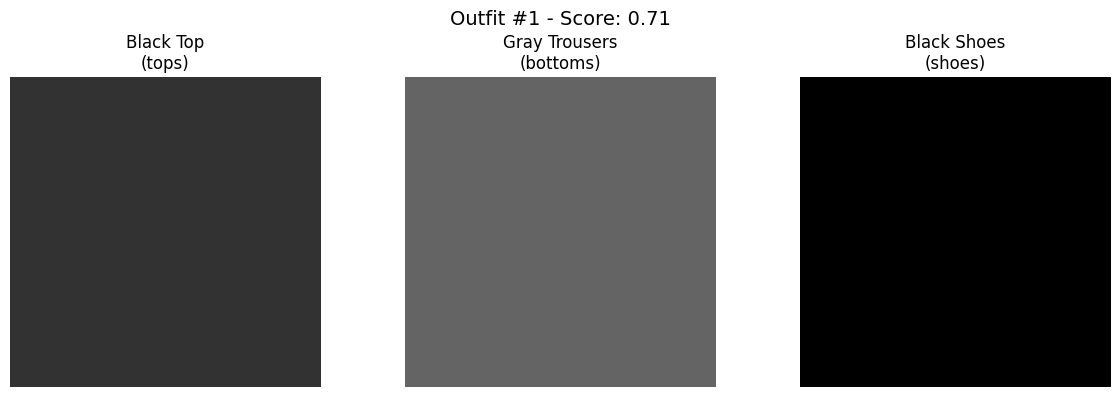

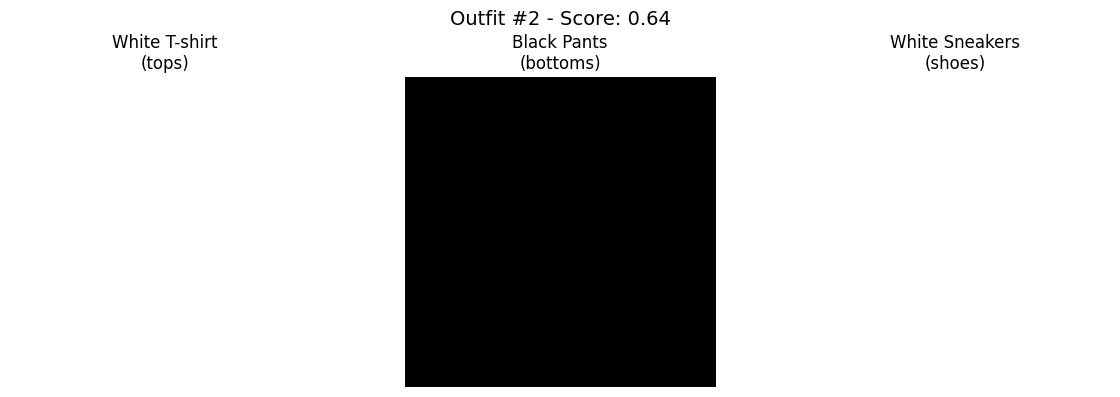

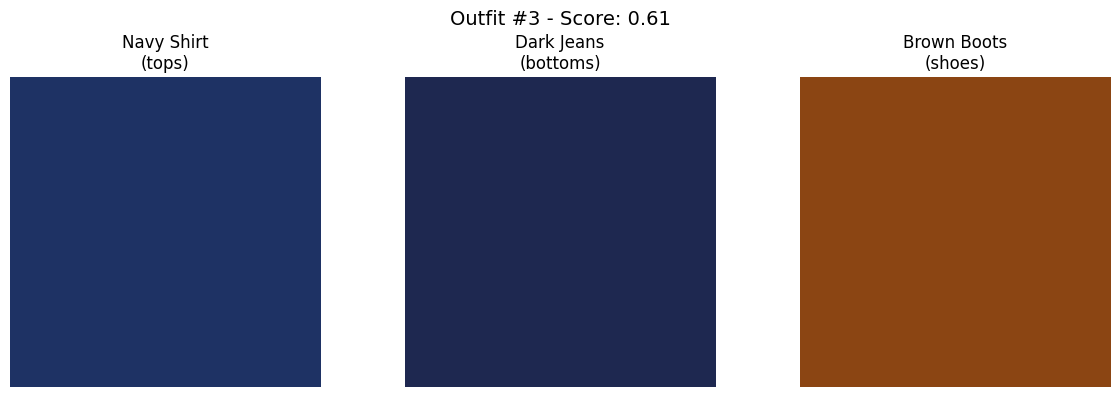

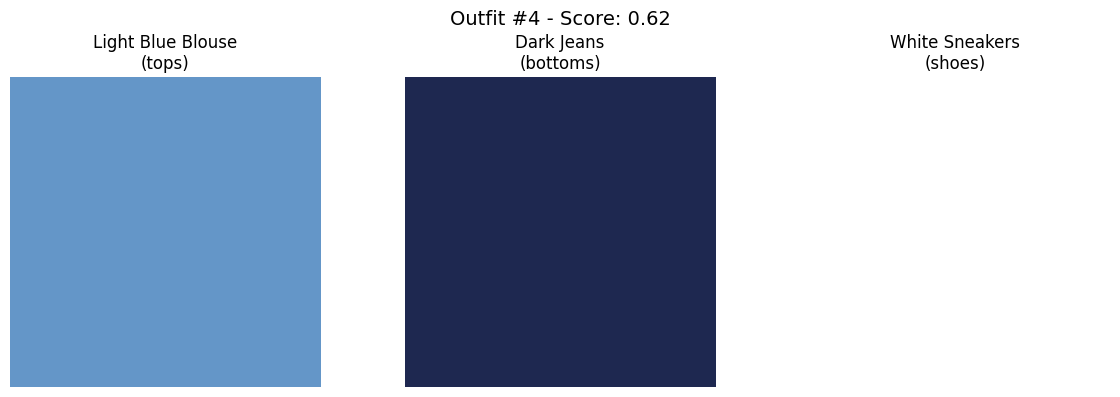

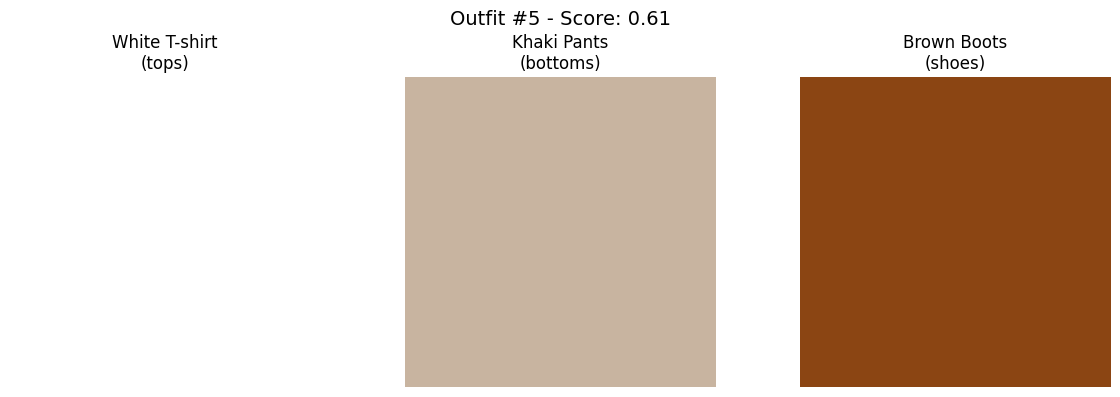

In [7]:
# Display generated outfits
def display_outfit(outfit, rank):
    """Display an outfit visually."""
    fig, axes = plt.subplots(1, len(outfit.items), figsize=(4*len(outfit.items), 4))
    if len(outfit.items) == 1:
        axes = [axes]
    
    for ax, item in zip(axes, outfit.items):
        # Create color block for visualization
        color = item.metadata.get('color_rgb', [128, 128, 128])
        color_block = np.ones((100, 100, 3), dtype=np.uint8) * np.array(color, dtype=np.uint8)
        
        ax.imshow(color_block)
        ax.set_title(f"{item.metadata.get('name', item.category)}\n({item.category})")
        ax.axis('off')
    
    fig.suptitle(f"Outfit #{rank} - Score: {outfit.score:.2f}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Display top 5 outfits
for i, outfit in enumerate(outfits[:5], 1):
    display_outfit(outfit, i)

## 4.4 Explain Recommendations

In [8]:
# Initialize explainer
explainer = OutfitExplainer(color_analyzer=ColorHarmonyAnalyzer())
quick_explainer = QuickExplainer()

# Explain top outfit
if outfits:
    top_outfit = outfits[0]
    explanation = explainer.explain(top_outfit)
    
    print("="*50)
    print("TOP OUTFIT EXPLANATION")
    print("="*50)
    print(f"\n{explanation.summary}")
    print(f"\nColor Analysis: {explanation.color_analysis}")
    print(f"\nCompatibility: {explanation.compatibility_analysis}")
    
    if explanation.strengths:
        print("\nStrengths:")
        for strength in explanation.strengths:
            print(f"  + {strength}")
    
    if explanation.suggestions:
        print("\nSuggestions:")
        for suggestion in explanation.suggestions:
            print(f"  * {suggestion}")

TOP OUTFIT EXPLANATION

This 71% compatible outfit includes: tops, bottoms, shoes. It works because neutral colors provide versatile foundation.

Color Analysis: This outfit features gray, black. The colors follow a neutral-pairing harmony.

Compatibility: This outfit has good compatibility. The strongest pairing is between the items with score 0.93. 

Strengths:
  + Neutral colors provide versatile foundation
  + Good overall compatibility

Suggestions:
  * Accessories could add a finishing touch


In [9]:
# Quick explanations for all outfits
print("\nQuick Summary of All Outfits:")
print("-" * 40)

for i, outfit in enumerate(outfits, 1):
    quick = quick_explainer.quick_explain(outfit)
    print(f"{i}. {quick}")


Quick Summary of All Outfits:
----------------------------------------
1. tops + bottoms + shoes - good match (71%)
2. tops + bottoms + shoes - decent match (64%)
3. tops + bottoms + shoes - decent match (61%)
4. tops + bottoms + shoes - decent match (62%)
5. tops + bottoms + shoes - decent match (61%)
6. tops + bottoms + shoes - decent match (61%)
7. tops + bottoms + shoes - decent match (60%)
8. tops + bottoms + shoes - moderate match (59%)
9. tops + bottoms + shoes - decent match (66%)
10. tops + bottoms + shoes - moderate match (58%)


## 4.5 Build Outfit Around Specific Item

Building outfit around: White T-shirt

Generated 5 outfits with anchor item


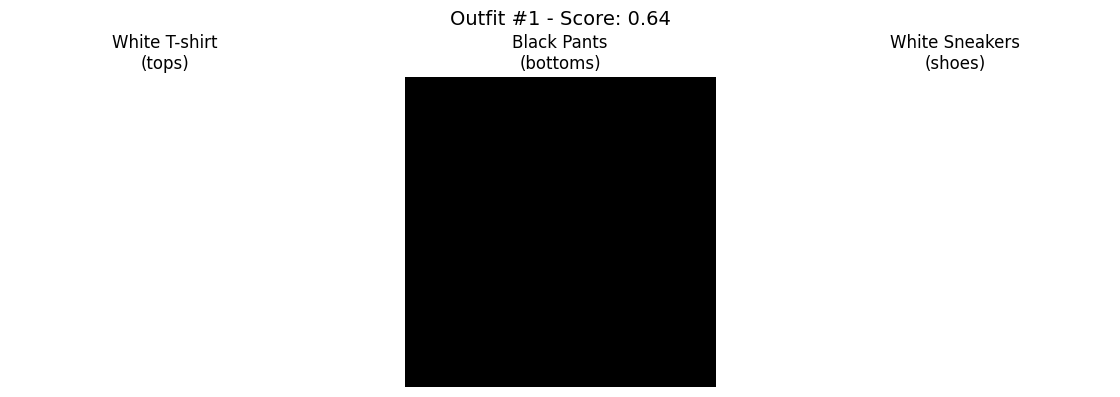

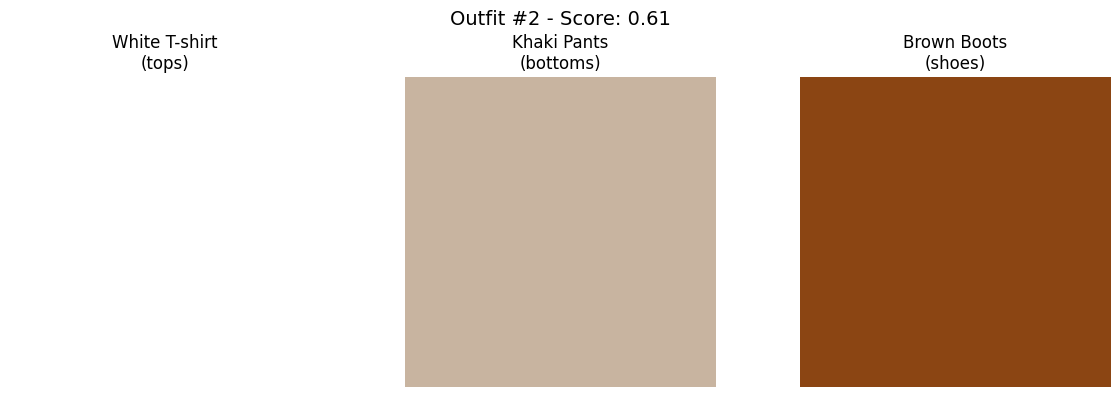

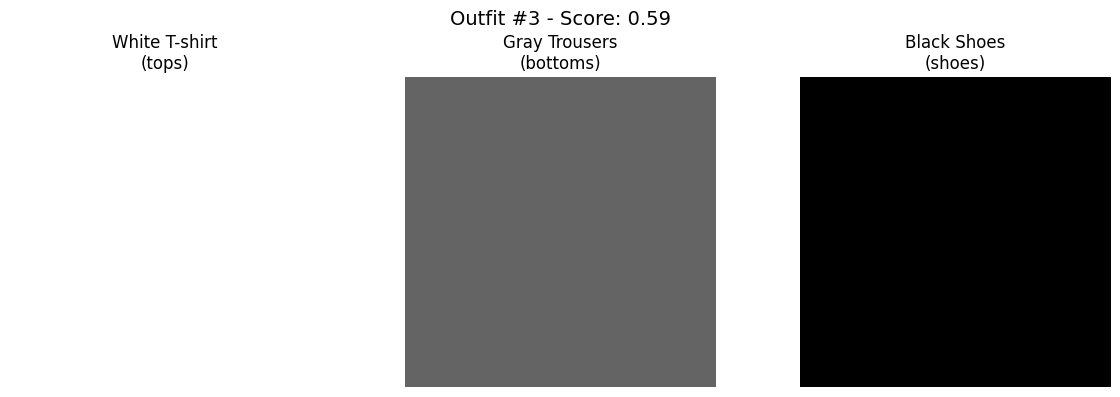

In [10]:
# Select an anchor item
tops_items = wardrobe.get_items_by_category("tops")
anchor = tops_items[0]  # First top

print(f"Building outfit around: {anchor.metadata.get('name', anchor.item_id)}")

# Generate outfits including this item
anchor_outfits = generator.generate_outfits(
    wardrobe=wardrobe,
    template=casual_template,
    anchor_item=anchor,
    max_outfits=5
)

print(f"\nGenerated {len(anchor_outfits)} outfits with anchor item")

# Display
for i, outfit in enumerate(anchor_outfits[:3], 1):
    display_outfit(outfit, i)

## 4.6 Suggest Additions

In [11]:
# Start with a partial outfit
partial_outfit = [tops_items[0]]  # Just a top

print(f"Current selection: {partial_outfit[0].metadata.get('name')}")
print("\nSuggested bottoms to pair with:")

# Get suggestions for bottoms
bottom_suggestions = generator.suggest_additions(
    current_items=partial_outfit,
    wardrobe=wardrobe,
    category="bottoms",
    top_k=3
)

for item, score in bottom_suggestions:
    print(f"  - {item.metadata.get('name')}: {score:.2f}")

Current selection: White T-shirt

Suggested bottoms to pair with:
  - Black Pants: 0.79
  - Khaki Pants: 0.72
  - Dark Jeans: 0.64


## Summary

In this notebook we:
1. Loaded all trained models
2. Created a sample wardrobe
3. Generated outfit recommendations using compatibility scoring
4. Explained why outfits work using color theory and compatibility analysis
5. Built outfits around specific items
6. Suggested additions to partial outfits

**Next Step:** Run notebook 05 for the full interactive demo